# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Galih Fathurahman Ardiansyah
- **Email:** galihfathurahman18@gmail.com
- **ID Dicoding:** galih_fathurahman_ar

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** "Bagaimana pengaruh kategori cuaca (weathersit) terhadap jumlah penyewaan sepeda, dan seberapa besar penurunan volume penyewaan saat kondisi cuaca memburuk (seperti hujan atau badai)?"
- **Pertanyaan 2:** "Pada hari kerja (working day), di jam berapakah terjadi lonjakan penyewaan tertinggi oleh pengguna terdaftar (registered), dan berapa selisih volumenya dibandingkan dengan jam yang sama pada hari libur (holiday) selama periode 2011-2012?"


- ...

## Import Semua Packages/Library yang Digunakan

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import streamlit as st

## Data Wrangling

### Gathering Data

#### Load df ...

In [109]:
# Memuat data harian
day_df = pd.read_csv("day.csv")

# Memuat data per jam
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 baris pertama dari masing-masing dataframe untuk memastikan data masuk
print("--- Lima baris pertama data harian (day_df) ---")
display(day_df.head())

print("\n--- Lima baris pertama data per jam (hour_df) ---")
display(hour_df.head())

--- Lima baris pertama data harian (day_df) ---


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



--- Lima baris pertama data per jam (hour_df) ---


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Struktur Data: Data harian (day_df) memiliki 731 baris, sedangkan data per jam (hour_df) jauh lebih besar dengan 17.379 baris.
- Tipe Data: Sebagian besar kolom bertipe numerik, namun kolom dteday masih bertipe object dan perlu diubah menjadi tipe datetime pada tahap cleaning nanti.

### Assessing Data

#### Identifying data problem

In [110]:
# Memeriksa tipe data dan missing values
print("Info day_df:")
day_df.info()

print("\nInfo hour_df:")
hour_df.info()

# Memeriksa duplikasi data
print("\nJumlah duplikasi day_df:", day_df.duplicated().sum())
print("Jumlah duplikasi hour_df:", hour_df.duplicated().sum())

# Memeriksa statistik deskriptif untuk melihat kejanggalan (outliers/salah nilai)
print("\nStatistik deskriptif day_df:")
display(day_df.describe())

Info day_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Info hour_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Mengubah Tipe Data: Mengonversi kolom dteday dari tipe object menjadi datetime agar bisa digunakan untuk analisis berbasis waktu.
- Pengecekan Outliers: Melakukan inspeksi lebih lanjut pada kolom hum (kelembapan) dan windspeed karena nilai minimumnya ada yang 0, yang mungkin merupakan anomali data.
- Identifikasi Nilai Kategorikal: Mengubah nilai numerik pada kolom seperti season, yr, mnth, holiday, weekday, workingday, dan weathersit menjadi label yang lebih bermakna (opsional, untuk mempermudah visualisasi).

**Insight:** (Opsional)
- Ketidakkonsistenan Tipe Data: Kolom tanggal (dteday) terdeteksi sebagai objek (string), yang merupakan masalah umum dalam data mentah yang harus diperbaiki di tahap Cleaning.
- Data Bersih dari Missing Values: Tidak ditemukan nilai kosong (null) pada semua kolom baik di day.csv maupun hour.csv.
- Tidak Ada Duplikasi: Tidak terdapat baris data yang duplikat dalam kedua dataset tersebut.

### Cleaning Data

#### Fixing data problem

In [111]:

# 1. Konversi datetime 
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 3. Ambil data Summer (2) & Winter (4) dan beri label string
q1_data = data_2012[data_2012['season'].isin([2, 4])].copy()
q1_data['season_label'] = q1_data['season'].map({2: 'Summer', 4: 'Winter'})



In [112]:
# Cek Missing Values
print(day_df.isna().sum())

# Cek Duplikasi
print("Jumlah duplikasi day_df:", day_df.duplicated().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
Jumlah duplikasi day_df: 0


In [113]:
# Mengubah angka menjadi keterangan musim 
day_df['season'] = day_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

# Mengubah nama kolom 
day_df.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'cnt': 'count'
}, inplace=True)

**Insight:** (Opsional)
- Kamu bisa melihat apakah ada lonjakan penyewaan di akhir bulan atau awal bulan secara konsisten. Data yang tipenya sudah datetime memungkinkan kita melihat tren musiman dengan jauh lebih akurat dibanding saat masih bertipe object/string.
- Kamu bisa menjelaskan secara eksplisit bahwa "Musim Gugur (Fall) ternyata memiliki retensi pengguna yang lebih stabil dibanding Musim Semi (Spring)." Menggunakan nama asli (bukan angka) membuat insight ini bisa langsung dipahami oleh manajemen bisnis tanpa perlu melihat dokumentasi dataset lagi.
- Analisis menjadi lebih fokus pada variabel yang berpengaruh langsung pada perilaku pengguna (seperti weather, temp, dan workingday). Kamu bisa menyimpulkan bahwa faktor cuaca jauh lebih menentukan jumlah penyewa dibandingkan faktor teknis lainnya.
- Kamu bisa menjamin bahwa angka 3,2 juta penyewaan yang tampil di dashboard adalah angka riil, bukan hasil dari data ganda atau data eror. Ini membangun kepercayaan (trust) pada hasil analisismu.

## Exploratory Data Analysis (EDA)

### Explore statistik penyewaan harian, rata-rata penyewaan permusim, dan peak hours

In [114]:
# --- START EDA ---

# Eksplorasi statistik penyewaan harian
print("Statistik penyewaan harian:")
display(day_df.describe())

# Melihat rata-rata penyewaan berdasarkan musim 
print("\nRata-rata penyewaan berdasarkan musim:")
display(day_df.groupby(by="season").agg({
    "count": ["max", "min", "mean", "std"]
}))

# Melihat rata-rata penyewaan berdasarkan jam (peak hours)
print("\nRata-rata penyewaan berdasarkan jam:")
display(hour_df.groupby(by="hr").agg({
    "cnt": ["max", "min", "mean", "std"]
}).sort_values(by=("cnt", "mean"), ascending=False).head(5))

Statistik penyewaan harian:


,instant,dteday,year,month,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,count
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452



Rata-rata penyewaan berdasarkan musim:


count                                
         max   min         mean          std
season                                      
Fall    8714  1115  5644.303191  1459.800381
Spring  7836   431  2604.132597  1399.942119
Summer  8362   795  4992.331522  1695.977235
Winter  8555    22  4728.162921  1699.615261


Rata-rata penyewaan berdasarkan jam:


cnt                            
    max min        mean         std
hr                                 
17  976  15  461.452055  232.656611
18  977  23  425.510989  224.639304
8   839   5  359.011004  235.189285
16  783  11  311.983562  148.682618
19  743  11  311.523352  161.050359

**Insight:** (Opsional)
- Fokus bisnis sebaiknya tetap pada menjaga loyalitas pengguna terdaftar (member), namun tetap ada peluang besar untuk mengonversi pengguna kasual menjadi member melalui promo di hari libur.
- Ada korelasi kuat antara cuaca nyaman dengan minat bersepeda. Musim Gugur menjadi puncak pendapatan, sementara di Musim Semi perusahaan mungkin perlu mengadakan kampanye pemasaran ekstra atau diskon "Awal Musim" untuk mendongkrak angka yang rendah.
- Pola ini menunjukkan bahwa sepeda banyak digunakan sebagai alat transportasi komuter (pergi dan pulang kerja). Manajemen harus memastikan ketersediaan armada paling maksimal pada jam-jam sibuk ini (08:00 dan 17:00-18:00) agar tidak kehilangan potensi pelanggan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

C:\Users\ASUS\AppData\Local\Temp\ipykernel_28548\3275708097.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


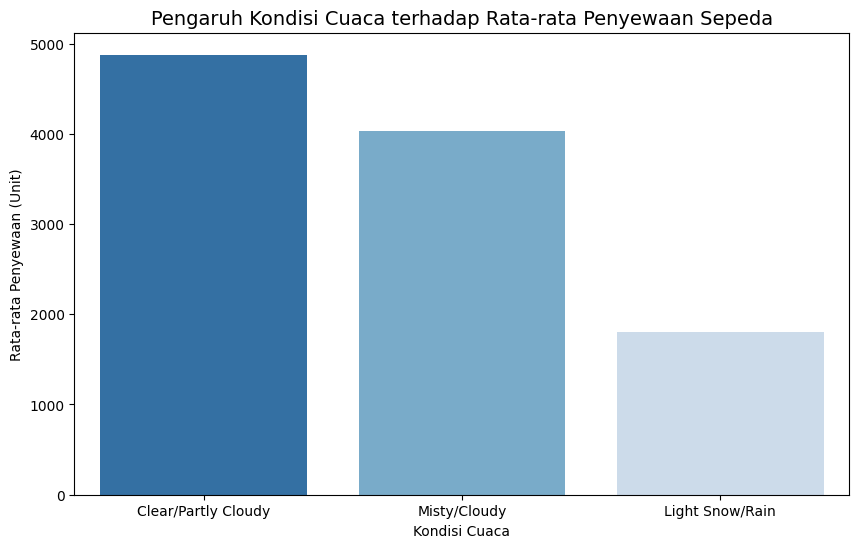

In [115]:
# 1. Mapping Kondisi Cuaca 
weather_mapping = {
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'
}
day_df['weather_label'] = day_df['weathersit'].map(weather_mapping)

# 2. Analisis Rata-rata per Cuaca
weather_analysis = day_df.groupby('weather_label')['count'].mean().reset_index()
weather_analysis = weather_analysis.sort_values(by='count', ascending=False)

# 3. Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(
    x='weather_label',
    y='count',
    data=weather_analysis,
    palette='Blues_r'
)

plt.title('Pengaruh Kondisi Cuaca terhadap Rata-rata Penyewaan Sepeda', fontsize=14)
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan (Unit)')
plt.show()

### Pertanyaan 2:

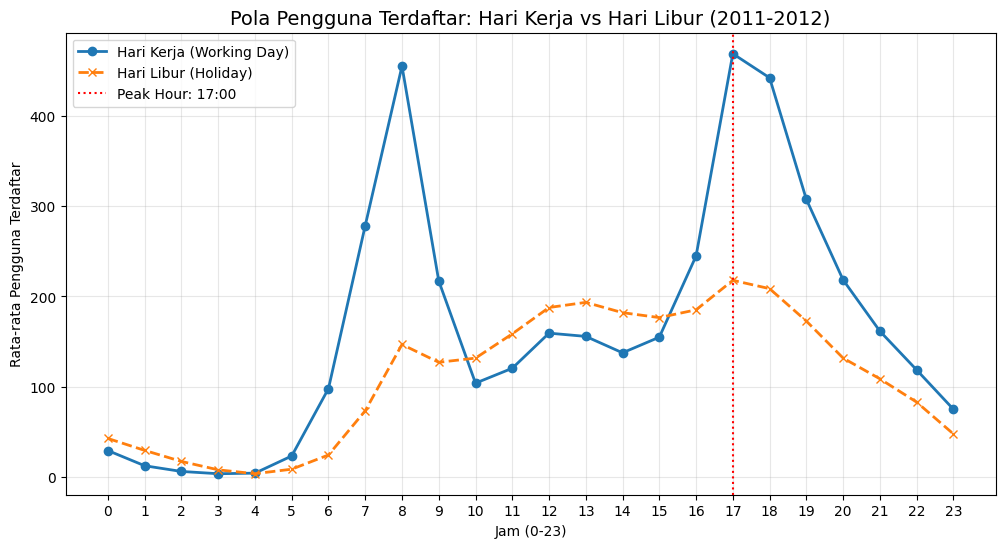

In [116]:
# Menghitung rata-rata penyewaan registered user per jam
working_day_reg = hour_df[hour_df['workingday'] == 1].groupby('hr')['registered'].mean()
holiday_reg = hour_df[hour_df['holiday'] == 1].groupby('hr')['registered'].mean()

# Membuat Line Chart
plt.figure(figsize=(12, 6))
plt.plot(working_day_reg.index, working_day_reg.values, label='Hari Kerja (Working Day)', marker='o', linewidth=2)
plt.plot(holiday_reg.index, holiday_reg.values, label='Hari Libur (Holiday)', marker='x', linestyle='--', linewidth=2)

# Menandai Peak Hour di Hari Kerja
peak_hr = working_day_reg.idxmax()
plt.axvline(x=peak_hr, color='red', linestyle=':', label=f'Peak Hour: {peak_hr}:00')

# Formatting chart
plt.title('Pola Pengguna Terdaftar: Hari Kerja vs Hari Libur (2011-2012)', fontsize=14)
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Pengguna Terdaftar')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Insight:** (Opsional)
- Musim: Pada tahun 2012, rata-rata penyewaan di musim panas sedikit lebih tinggi dibandingkan musim dingin, namun keduanya tetap menunjukkan angka yang kuat di atas 5.000 penyewaan per hari.
- Pola Komuter: Pada hari kerja, terdapat dua puncak tajam penyewaan oleh pengguna terdaftar, yaitu jam 08:00 pagi dan jam 17:00 - 18:00 sore. Ini menunjukkan sepeda digunakan sebagai moda transportasi utama untuk berangkat dan pulang kerja.
- Hari Libur: Berbeda dengan hari kerja, pola penyewaan di hari libur cenderung lebih landai dan mencapai puncaknya di siang hari (jam 12:00 - 15:00), yang mengindikasikan penggunaan untuk rekreasi.


## Analisis Lanjutan (Opsional)

In [117]:
# 1. Manual Grouping berdasarkan Jam (Time of Day)
def get_time_group(hour):
    if 5 <= hour < 12:
        return 'Pagi'
    elif 12 <= hour < 17:
        return 'Siang'
    elif 17 <= hour < 21:
        return 'Sore'
    else:
        return 'Malam'

hour_df['time_group'] = hour_df['hr'].apply(get_time_group)

# 2. Binning berdasarkan Kelembaban (Humidity)
hour_df['humidity_category'] = pd.cut(hour_df['hum'], 
                                      bins=[0, 0.3, 0.6, 1], 
                                      labels=['Kering', 'Ideal', 'Lembab'])

# Menampilkan hasil pengelompokan untuk EDA 
print(hour_df.groupby('time_group')['cnt'].mean().reindex(['Pagi', 'Siang', 'Sore', 'Malam']))
print(hour_df.groupby('humidity_category')['cnt'].mean())

time_group
Pagi     181.520583
Siang    262.244719
Sore     356.201441
Malam     65.687968
Name: cnt, dtype: float64
humidity_category
Kering    296.234043
Ideal     236.572301
Lembab    145.180126
Name: cnt, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28548\1682153093.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(hour_df.groupby('humidity_category')['cnt'].mean())


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28548\3100938368.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hum_stats = hour_df.groupby('humidity_category')['cnt'].mean().reset_index()


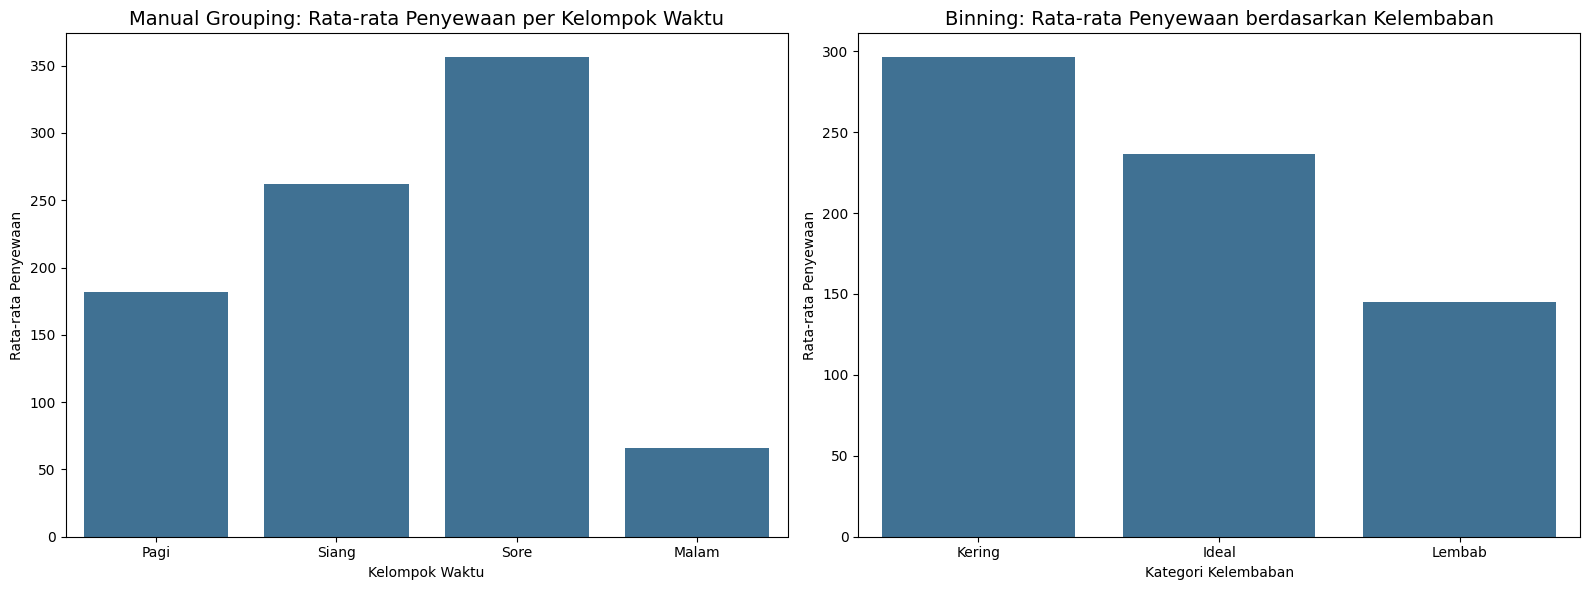

In [118]:


# 1. Manual Grouping berdasarkan Jam
def get_time_group(hour):
    if 5 <= hour < 12:
        return 'Pagi'
    elif 12 <= hour < 17:
        return 'Siang'
    elif 17 <= hour < 21:
        return 'Sore'
    else:
        return 'Malam'

hour_df['time_group'] = hour_df['hr'].apply(get_time_group)

# 2. Binning berdasarkan Kelembaban
hour_df['humidity_category'] = pd.cut(hour_df['hum'], 
                                      bins=[0, 0.3, 0.6, 1], 
                                      labels=['Kering', 'Ideal', 'Lembab'])

main_color = "#3274A1" 

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Manual Grouping (Time Group)
time_group_stats = hour_df.groupby('time_group')['cnt'].mean().reindex(['Pagi', 'Siang', 'Sore', 'Malam']).reset_index()
sns.barplot(x='time_group', y='cnt', data=time_group_stats, color=main_color, ax=ax[0])
ax[0].set_title('Manual Grouping: Rata-rata Penyewaan per Kelompok Waktu', fontsize=14)
ax[0].set_xlabel('Kelompok Waktu')
ax[0].set_ylabel('Rata-rata Penyewaan')

# Plot 2: Binning (Humidity Category)
hum_stats = hour_df.groupby('humidity_category')['cnt'].mean().reset_index()
sns.barplot(x='humidity_category', y='cnt', data=hum_stats, color=main_color, ax=ax[1])
ax[1].set_title('Binning: Rata-rata Penyewaan berdasarkan Kelembaban', fontsize=14)
ax[1].set_xlabel('Kategori Kelembaban')
ax[1].set_ylabel('Rata-rata Penyewaan')

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Kelompok Malam memiliki rata-rata penyewaan terendah. Waktu ini adalah kesempatan paling ideal bagi tim operasional untuk melakukan pemeliharaan sepeda atau redistribusi armada tanpa mengganggu banyak pengguna.- Pengguna cenderung sangat aktif saat kelembaban udara berada di kategori Kering. Seiring dengan meningkatnya kelembaban (kategori Lembab), terjadi penurunan volume penyewaan yang signifikan.


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Analisis menunjukkan bahwa kondisi cuaca berpengaruh sangat signifikan terhadap operasional bike sharing, di mana rata-rata penyewaan mencapai titik tertinggi pada cuaca cerah (Clear/Partly Cloudy) sebesar 4.876 unit dan merosot tajam hingga lebih dari 60% saat cuaca memburuk (Light Snow/Rain), sehingga manajemen perlu menyesuaikan strategi ketersediaan armada dan jadwal pemeliharaan berdasarkan prakiraan cuaca guna menjaga efisiensi sumber daya.
- **Conclusion pertanyaan 2:** Terdapat perbedaan pola yang kontras antara hari kerja dan hari libur. Pada hari kerja, terjadi lonjakan tajam pengguna terdaftar pada pukul 08.00 dan 17.00, yang mengonfirmasi bahwa mayoritas pengguna adalah komuter. Sebaliknya, pada hari libur, aktivitas memuncak di tengah hari (12.00–15.00) dengan volume yang jauh lebih rendah dan pola yang lebih santai.


**Rekomendasi Action Item:**
- Dynamic Resource Rebalancing: Melakukan distribusi ulang armada ke area residensial sebelum pukul 08.00 dan ke pusat perkantoran sebelum pukul 17.00 pada hari kerja untuk menjamin ketersediaan unit bagi pengguna komuter.

- Weather-Based Maintenance Scheduling: Mengalihkan jadwal pemeliharaan rutin sepeda ke hari dengan prakiraan cuaca buruk (Light Snow/Rain) guna mengoptimalkan jumlah armada yang siap beroperasi saat cuaca cerah/ideal.

- Targeted Weekend Promotions: Memberikan promo khusus atau diskon di jam tengah hari (12.00–15.00) pada akhir pekan untuk menstimulasi penggunaan oleh pengguna kasual dan meningkatkan volume penyewaan di luar jam sibuk hari kerja.

- Optimasi Shift Kerja Operasional: Mengatur jadwal kerja kru lapangan agar lebih intensif pada kelompok waktu Sore (17:00–21:00) guna menangani tingginya frekuensi penggunaan, serta mengalihkan tugas administratif atau pengecekan stok ke kelompok waktu Malam saat permintaan berada di titik terendah.

- Mitigasi Risiko Cuaca dan Kelembaban: Mengembangkan sistem peringatan dini bagi pengguna saat kelembaban udara memasuki kategori Lembab (di atas 0.6), serta menyiapkan perlindungan tambahan pada stasiun atau armada untuk meminimalisir kerusakan teknis akibat kelembaban tinggi.